In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

In [15]:
df = pd.read_csv("../data/soil_crop_dataset.csv")

# Normalise column names to lowercase for convenience
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df.head(50)

,temperature,humidity,moisture,soil_type,nitrogen,ph,crop_type
0,18.8,57.4,40.7,loamy,193.9,7.54,Sugar Beet
1,23.9,68.0,68.9,loamy,119.3,5.73,Tomato
2,6.4,46.7,26.5,loamy,74.2,5.44,Rye
3,11.3,53.5,27.4,clayey,53.5,5.96,Rye
4,25.5,69.5,50.5,sandy,124.4,6.23,Soybean
5,18.7,66.7,37.7,black,141.2,6.20,Wheat
6,15.3,83.4,60.5,loamy,147.7,5.68,Potato
7,18.2,46.9,55.5,loamy,175.5,5.96,Corn
8,15.1,72.1,51.2,clayey,126.6,6.11,Oats
9,17.0,40.5,28.6,loamy,141.1,6.66,Cherry


In [16]:
print(f"Shape : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"\nColumns : {list(df.columns)}")
df.dtypes

Shape : (10400, 7)
Missing values : 0
Duplicate rows : 0

Columns : ['temperature', 'humidity', 'moisture', 'soil_type', 'nitrogen', 'ph', 'crop_type']


temperature    float64
humidity       float64
moisture       float64
soil_type       object
nitrogen       float64
ph             float64
crop_type       object
dtype: object

In [17]:
df.describe().round(2)

,temperature,humidity,moisture,nitrogen,ph
count,10400.00,10400.00,10400.00,10400.00,10400.00
mean,18.00,61.36,41.14,138.27,6.41
std,5.38,11.38,14.57,47.28,0.51
min,3.10,28.00,8.00,30.70,4.67
25%,14.00,53.10,28.80,104.70,6.06
50%,17.80,61.60,40.50,130.30,6.43
75%,22.30,69.80,53.30,171.10,6.77
max,32.40,91.10,78.70,317.20,8.21


In [18]:
df.describe()

,temperature,humidity,moisture,nitrogen,ph
count,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000
mean,17.999913,61.361212,41.137538,138.273452,6.412125
std,5.377241,11.383598,14.574555,47.280570,0.505739
min,3.100000,28.000000,8.000000,30.700000,4.670000
25%,14.000000,53.100000,28.800000,104.700000,6.060000
50%,17.800000,61.600000,40.500000,130.300000,6.430000
75%,22.300000,69.800000,53.300000,171.100000,6.770000
max,32.400000,91.100000,78.700000,317.200000,8.210000


## Crop Type Distribution

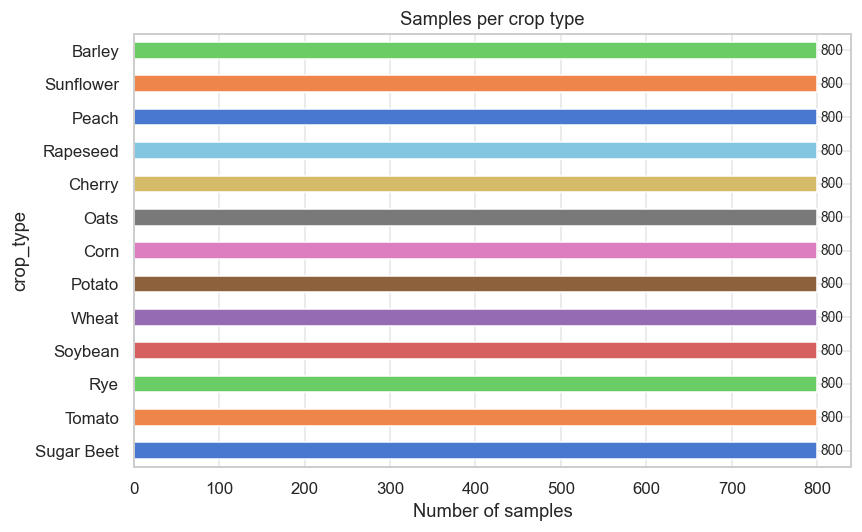

crop_type
Sugar Beet    800
Tomato        800
Rye           800
Soybean       800
Wheat         800
Potato        800
Corn          800
Oats          800
Cherry        800
Rapeseed      800
Peach         800
Sunflower     800
Barley        800


In [19]:
counts = df["crop_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
counts.plot(kind="barh", ax=ax, color=sns.color_palette("muted", len(counts)))
ax.set_xlabel("Number of samples")
ax.set_title("Samples per crop type")
for i, v in enumerate(counts):
    ax.text(v + 4, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(counts.to_string())

## Feature Distributions by Crop

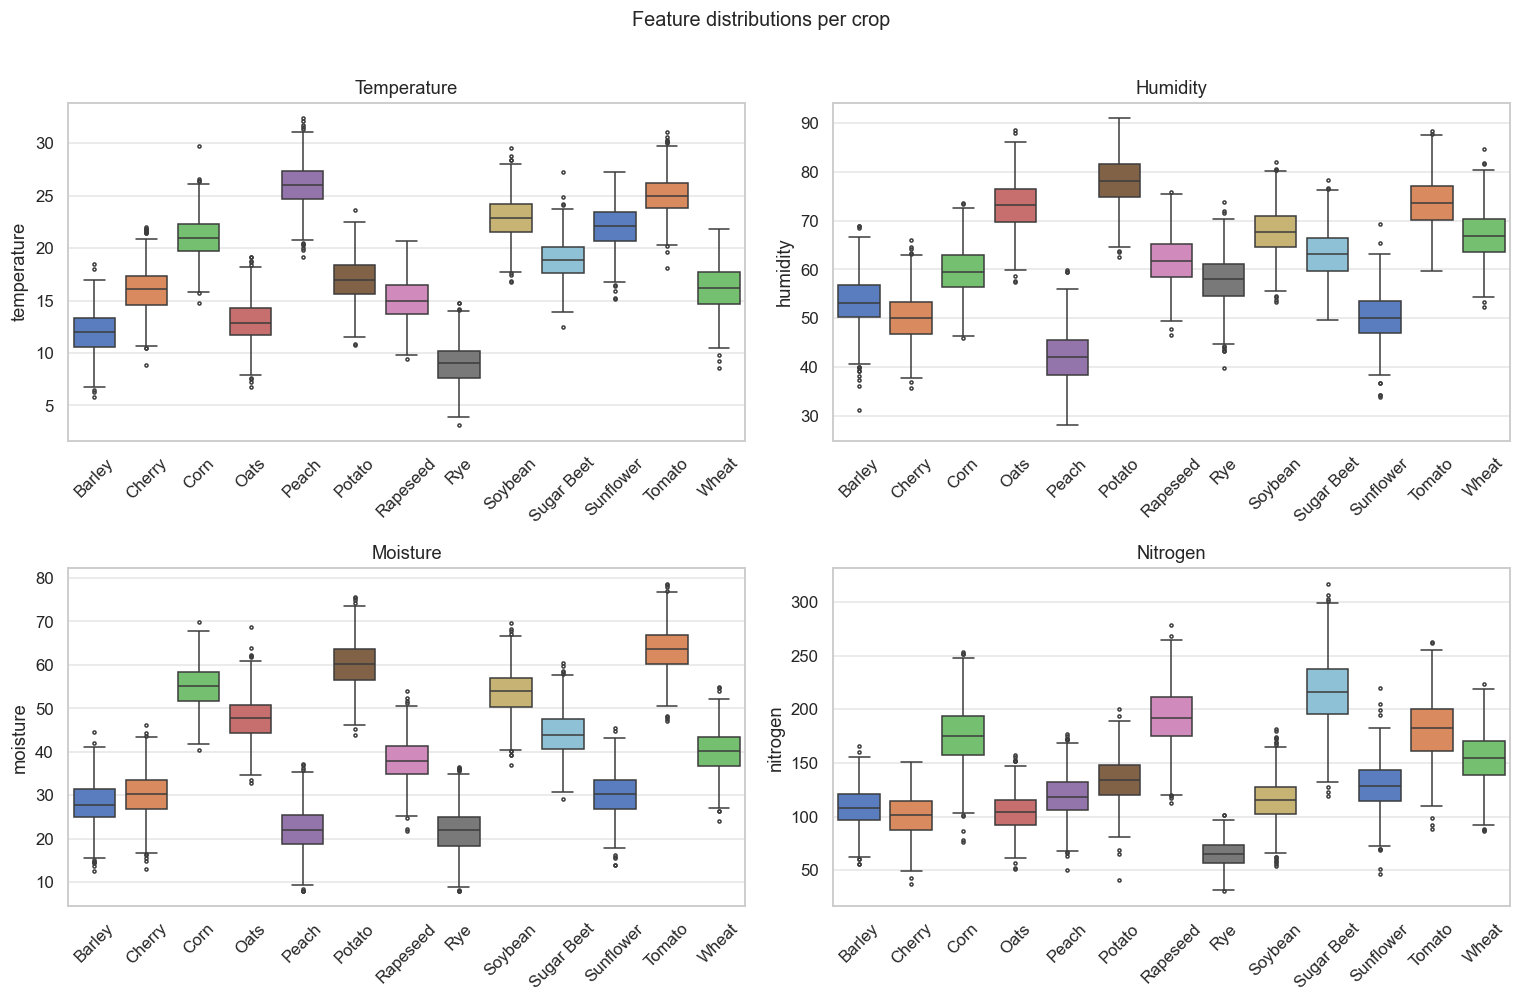

In [20]:
features = ["temperature", "humidity", "moisture", "nitrogen"]
crop_order = sorted(df["crop_type"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feat in zip(axes.flat, features):
    sns.boxplot(
        data=df, x="crop_type", y=feat, order=crop_order,
        palette="muted", ax=ax, fliersize=2,
    )
    ax.set_title(feat.capitalize())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Feature distributions per crop", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Soil Type Distribution

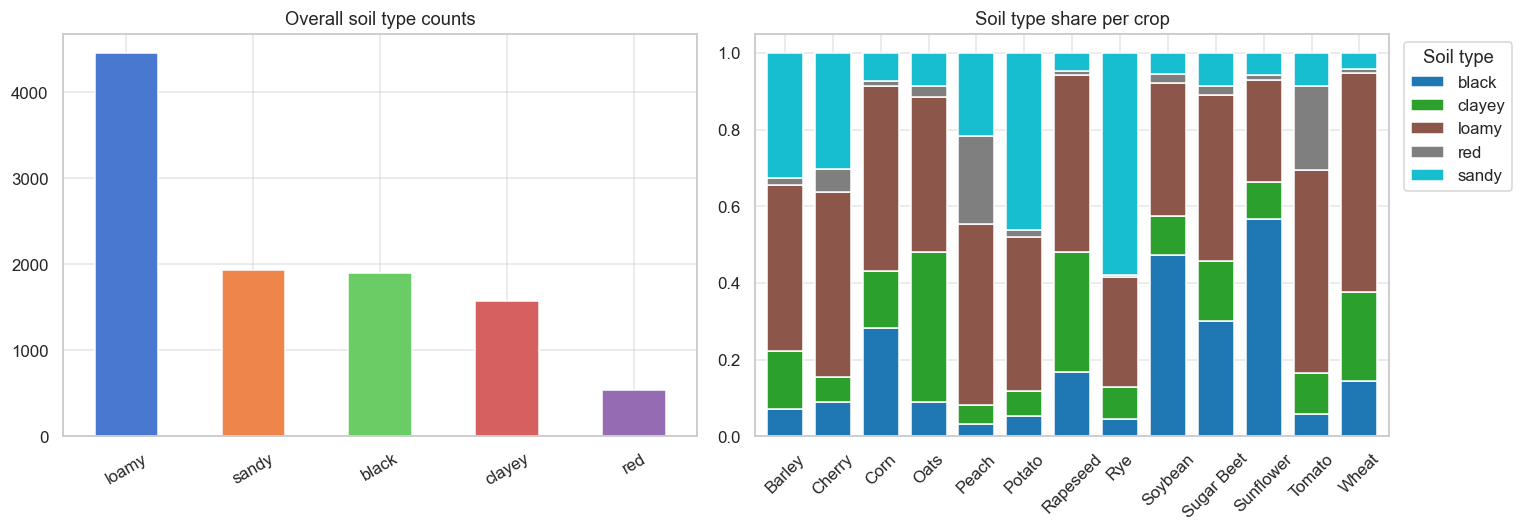

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall soil type counts
soil_counts = df["soil_type"].value_counts()
soil_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted", len(soil_counts)))
axes[0].set_title("Overall soil type counts")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Soil type share per crop (stacked bar)
soil_crop = (
    df.groupby(["crop_type", "soil_type"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
soil_crop.loc[crop_order].plot(
    kind="bar", stacked=True, ax=axes[1],
    colormap="tab10", width=0.75,
)
axes[1].set_title("Soil type share per crop")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Soil type", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Mean Feature Values per Crop

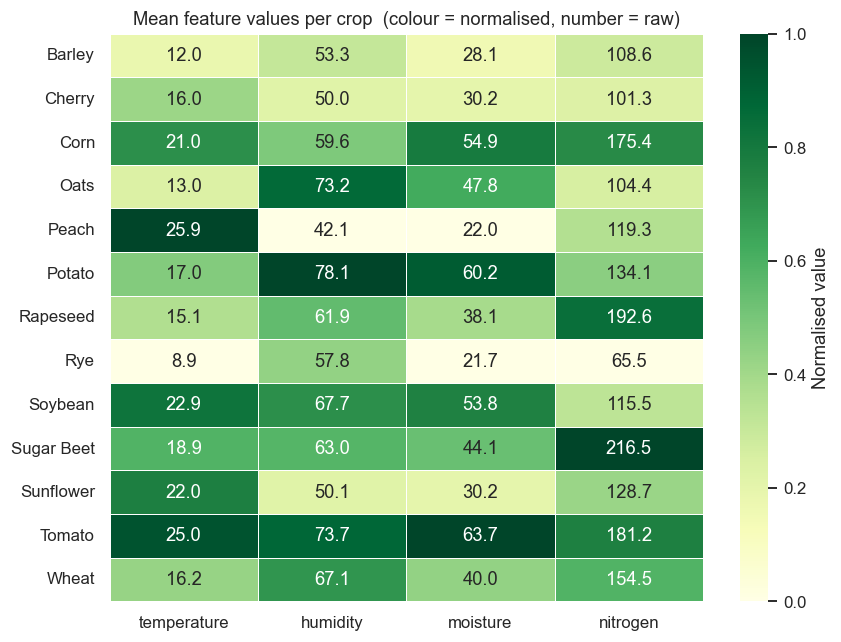

In [22]:
means = (
    df.groupby("crop_type")[features]
    .mean()
    .round(1)
    .loc[crop_order]
)

# Normalise each feature to 0-1 so all columns are on the same scale
means_norm = (means - means.min()) / (means.max() - means.min())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    means_norm, annot=means.values, fmt=".1f",
    cmap="YlGn", linewidths=0.4, ax=ax,
    cbar_kws={"label": "Normalised value"},
)
ax.set_title("Mean feature values per crop  (colour = normalised, number = raw)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Temperature vs Nitrogen  (coloured by crop)

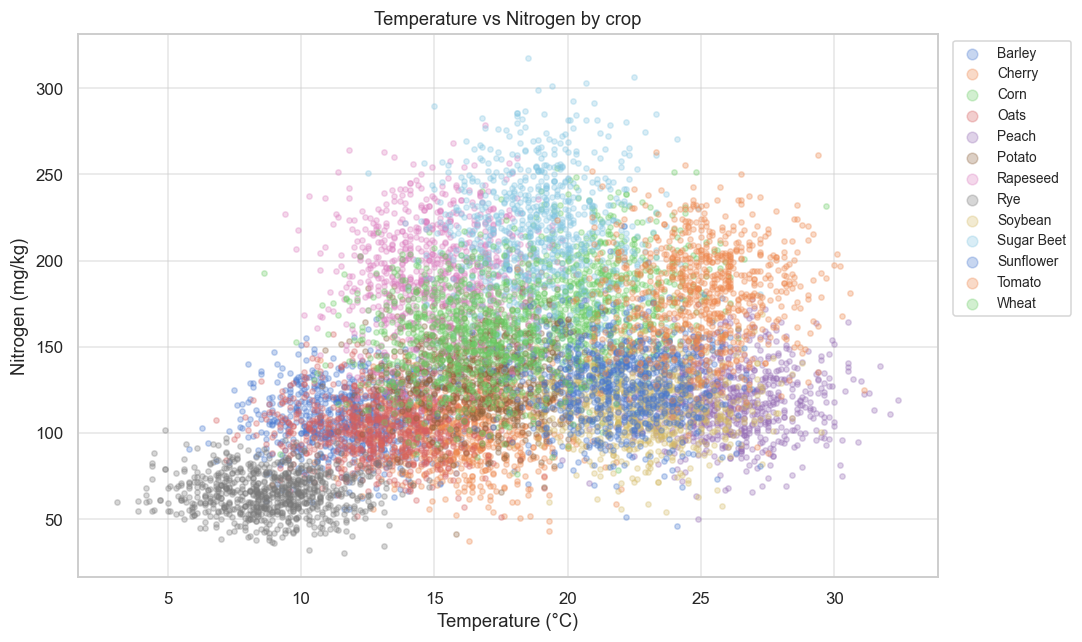

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
for crop in crop_order:
    sub = df[df["crop_type"] == crop]
    ax.scatter(sub["temperature"], sub["nitrogen"], label=crop, alpha=0.3, s=12)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Nitrogen (mg/kg)")
ax.set_title("Temperature vs Nitrogen by crop")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()